In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import pearsonr

In [24]:
# 데이터 로드
df = pd.read_csv(r'C:\programming\mystery_dungeon_anal\simulation_results_2.csv')

# 오류 해결을 위해 이 한 줄을 반드시 추가해야 합니다.
df['Waste_Tick'] = df['Used_Tick'] - df['Optimal_Tick']


In [25]:
print(*df.columns, sep="\n")

Seed
Spawn_Strategy
Initial_Drones_XY
Goal_X
Goal_Y
Optimal_Tick
Used_Tick
Map_Coverage_%
Spawn_Fail_Count
Backtrack_Count
Total_Spawned
Success
Waste_Tick


C:\Users\user\AppData\Local\Temp\ipykernel_21748\1164475288.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Spawn_Strategy', y=ind_var, ax=axes[0], palette='viridis')


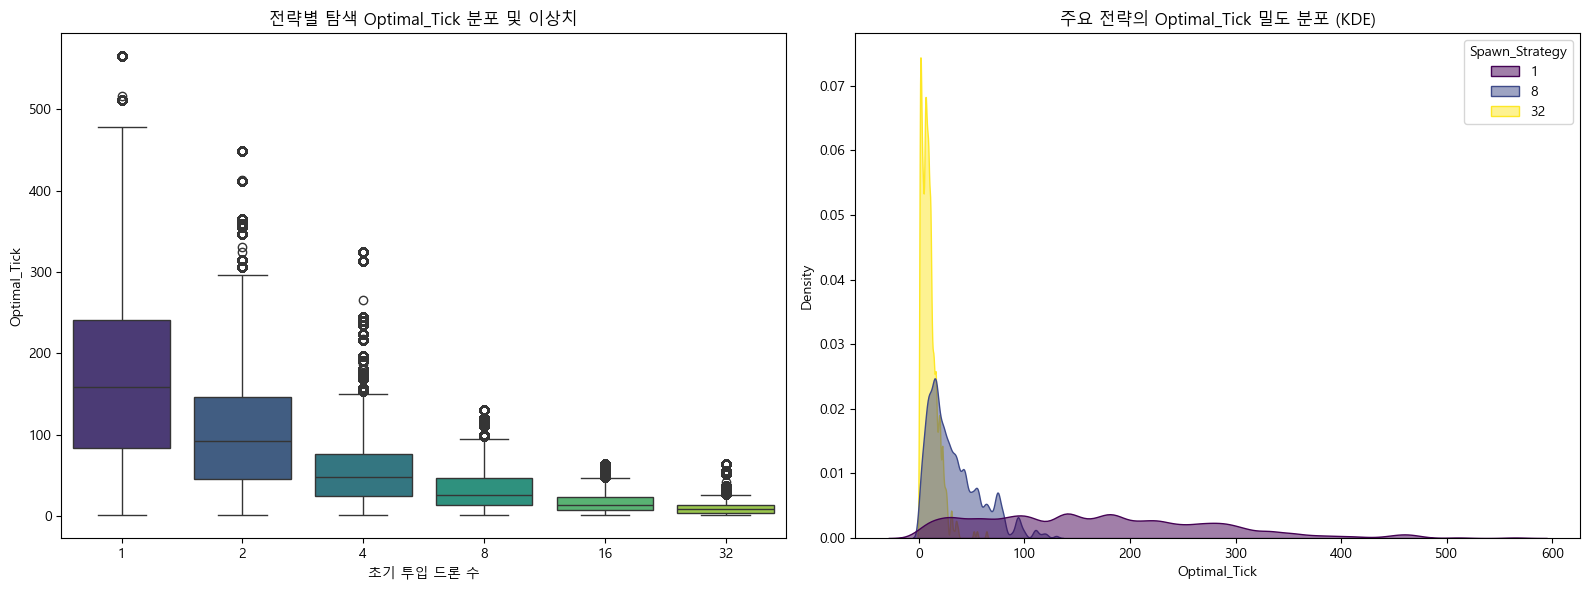

=== 초기 투입 드론 수에 따른 Optimal_Tick 첨도 ===
Spawn_Strategy
1     0.049256
2     1.206075
4     5.457300
8     0.809709
16    0.833803
32    7.439865
Name: Optimal_Tick, dtype: float64


In [26]:


# 한글 폰트 설정 (환경에 맞게 수정 필요)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 독립변수 설정
# ind_var = "Waste_Tick"
# ind_var = "Used_Tick"
ind_var = "Optimal_Tick"

# 2. 시각화 (박스 플롯 & 밀도 그래프)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# [왼쪽] 박스 플롯: 극단적 이상치 확인
sns.boxplot(data=df, x='Spawn_Strategy', y=ind_var, ax=axes[0], palette='viridis')
axes[0].set_title(f'전략별 탐색 {ind_var} 분포 및 이상치')
axes[0].set_xlabel('초기 투입 드론 수')
axes[0].set_ylabel(f'{ind_var}')

# [오른쪽] 밀도 그래프: 분포의 형태 확인 (비교를 위해 1, 8, 32대만 필터링)
sns.kdeplot(data=df[df['Spawn_Strategy'].isin([1, 8, 32])],
            x=ind_var, hue='Spawn_Strategy', fill=True, common_norm=False, 
            palette='viridis', ax=axes[1], alpha=0.5)
axes[1].set_title(f'주요 전략의 {ind_var} 밀도 분포 (KDE)')
axes[1].set_xlabel(f'{ind_var}')

plt.tight_layout()
plt.savefig('BOX_PLOT.png', transparent=True)
plt.show()

# 3. 전략별 첨도(Kurtosis) 수치 추출
print(f"=== 초기 투입 드론 수에 따른 {ind_var} 첨도 ===")
kurtosis_results = df.groupby('Spawn_Strategy')[ind_var].apply(pd.Series.kurtosis)
print(kurtosis_results)


In [30]:


# 1. Used_Tick을 종속변수로 하는 OLS 모델 피팅
# C()를 사용하여 Spawn_Strategy를 범주형 변수로 명시적으로 처리

model_used_tick = ols('Waste_Tick ~ C(Spawn_Strategy)', data=df).fit()
#model_used_tick = ols('Optimal_Tick ~ C(Spawn_Strategy)', data=df).fit()
# 기존: 'Used_Tick ~ C(Spawn_Strategy)'
# 변경: 전략과 운(Optimal_Tick)을 동시에 고려한 다중 모델
# model_used_tick = ols('Used_Tick ~ C(Spawn_Strategy) + Optimal_Tick', data=df).fit()
print(model_used_tick.summary())

# 2. ANOVA 테이블 생성 및 F값 분석
anova_table = sm.stats.anova_lm(model_used_tick, typ=2)

print("\n=== [1단계] Used_Tick 기반 일원분산분석(ANOVA) 결과 ===")
print(anova_table)

f_value = anova_table.loc['C(Spawn_Strategy)', 'F']
p_value = anova_table.loc['C(Spawn_Strategy)', 'PR(>F)']
print(f"\n* F-Value: {f_value:.2f} (전략 간 속도 차이가 통계적으로 매우 큼을 의미)")
print(f"* P-Value: {p_value:.4e}")

# 3. 모델의 설명력(R-squared) 추출
print("\n=== [2단계] OLS 모델의 설명력 (R-squared) 분석 ===")
r_squared = model_used_tick.rsquared
print(f"* R-squared (결정계수): {r_squared:.4f}")

# 4. 잔차 변동성 해석 출력
unexplained_variance = (1 - r_squared) * 100
print(f"-> [인사이트] 드론 투입 전략이 탐색 시간에 미치는 영향력은 {r_squared*100:.1f}%에 불과합니다.")
print(f"-> 나머지 {unexplained_variance:.1f}%의 변동성은 모델이 설명하지 못하는 영역, 즉 '목적지 스폰 위치에 따른 초기 물리적 거리(운)'에 의해 지배되고 있음을 증명합니다.")

                            OLS Regression Results                            
Dep. Variable:             Waste_Tick   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                 1.674e+04
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        03:44:35   Log-Likelihood:            -3.6070e+06
No. Observations:              920802   AIC:                         7.214e+06
Df Residuals:                  920796   BIC:                         7.214e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

=== [최종 검증] 교란 변수(운)와 실제 소요 시간의 상관관계 ===
* 피어슨 상관계수 (r): 0.9878
* P-Value: 0.0000e+00
* 단일 변수(운) 모델의 설명력 (R-squared): 0.9758



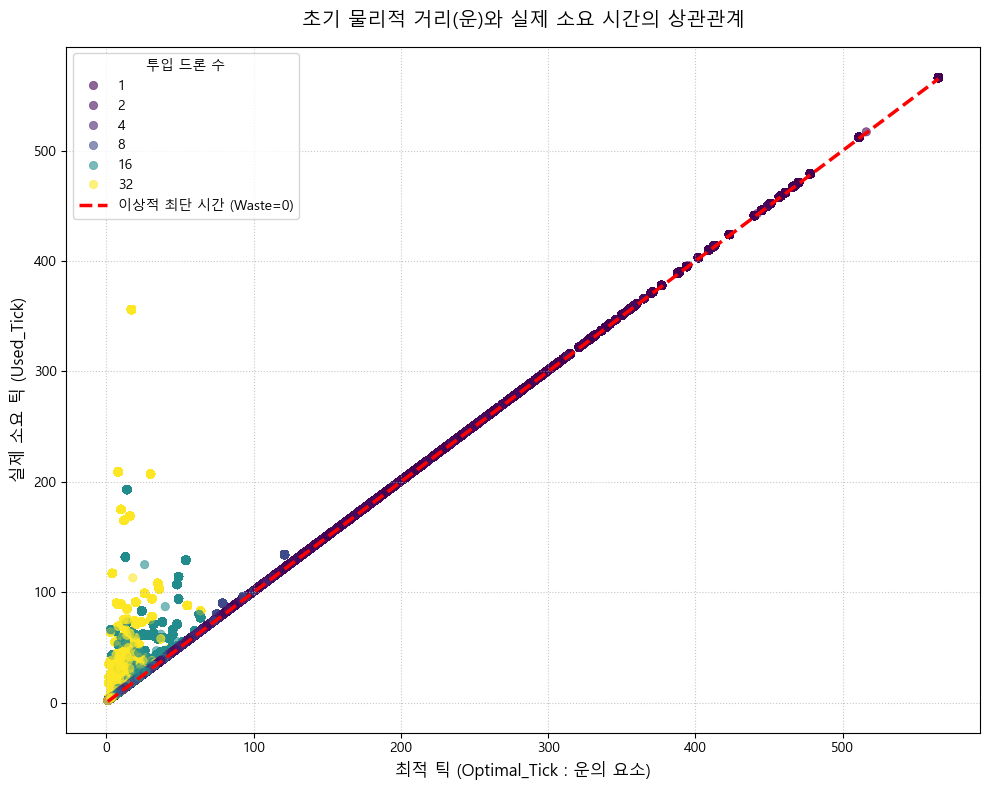

In [28]:


# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드 및 파생 변수 확인
# df = pd.read_csv('simulation_results.csv')
# df['Waste_Tick'] = df['Used_Tick'] - df['Optimal_Tick']  # 이전 단계에서 추가됨

print("=== [최종 검증] 교란 변수(운)와 실제 소요 시간의 상관관계 ===")

# 2. 피어슨 상관계수(Pearson Correlation) 도출
corr, p_val = pearsonr(df['Optimal_Tick'], df['Used_Tick'])
print(f"* 피어슨 상관계수 (r): {corr:.4f}")
print(f"* P-Value: {p_val:.4e}")

# 3. 운(Optimal_Tick) 하나만으로 모델을 만들었을 때의 설명력 확인
model_luck = sm.OLS.from_formula('Used_Tick ~ Optimal_Tick', data=df).fit()
print(f"* 단일 변수(운) 모델의 설명력 (R-squared): {model_luck.rsquared:.4f}\n")

# 4. 시각화: 산점도 및 이상적인 기준선(Baseline) 
plt.figure(figsize=(10, 8))

# 전략별로 색상을 다르게 분포 표시
sns.scatterplot(data=df, x='Optimal_Tick', y='Used_Tick', hue='Spawn_Strategy', 
                palette='viridis', alpha=0.6, edgecolor=None)

# 수학적 절대 한계선 (y = x, 즉 낭비 틱이 0인 완벽한 상태)
min_val = df['Optimal_Tick'].min()
max_val = df['Optimal_Tick'].max()
plt.plot([min_val, max_val], [min_val, max_val], 
         color='red', linestyle='--', linewidth=2.5, label='이상적 최단 시간 (Waste=0)')

plt.title('초기 물리적 거리(운)와 실제 소요 시간의 상관관계', fontsize=14, pad=15)
plt.xlabel('최적 틱 (Optimal_Tick : 운의 요소)', fontsize=12)
plt.ylabel('실제 소요 틱 (Used_Tick)', fontsize=12)
plt.legend(title='투입 드론 수', loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_21748\3804752113.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Spawn_Strategy', y='Optimal_Tick', palette='Blues')


=== 전략별 물리적 최단 거리(운) 평균값 ===
Spawn_Strategy
1     168.859885
2     106.038425
4      57.091942
8      33.126991
16     16.414102
32      9.740908
Name: Optimal_Tick, dtype: float64


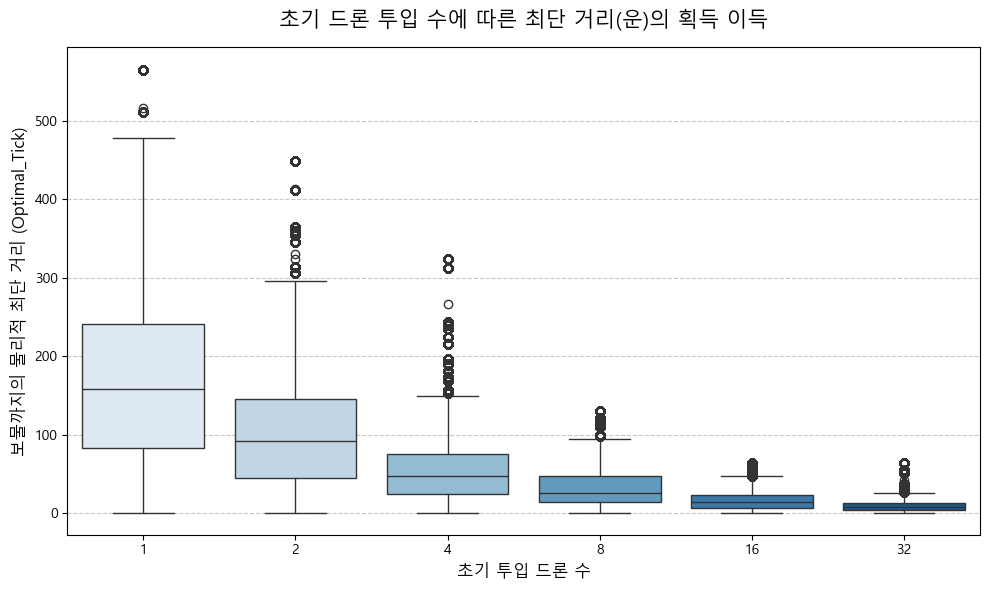

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# df = pd.read_csv('simulation_results.csv')

plt.figure(figsize=(10, 6))

# 운(Optimal_Tick)의 분포를 전략별로 시각화
sns.boxplot(data=df, x='Spawn_Strategy', y='Optimal_Tick', palette='Blues')

plt.title('초기 드론 투입 수에 따른 최단 거리(운)의 획득 이득', fontsize=15, pad=15)
plt.xlabel('초기 투입 드론 수', fontsize=12)
plt.ylabel('보물까지의 물리적 최단 거리 (Optimal_Tick)', fontsize=12)

# 각 전략별 운(Optimal_Tick)의 평균값 출력
means = df.groupby('Spawn_Strategy')['Optimal_Tick'].mean()
print("=== 전략별 물리적 최단 거리(운) 평균값 ===")
print(means)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()